# So sánh thời gian chạy: Apriori / Apriori+HashTree / FP-Growth

Biểu đồ đường với:
- **Trục X**: Min Support (số giao dịch tối thiểu)
- **Trục Y**: Thời gian thực thi (giây)
- **3 đường**: Apriori, Apriori+HashTree, FP-Growth

In [7]:
import sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
warnings.filterwarnings('ignore')

from src.algorithms.apriori import Apriori
from src.algorithms.fp_growth import FPGrowth
from src.mining import DatasetLoader

# ── Load dữ liệu ──────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
loader = DatasetLoader(DATA_DIR)
transactions = loader.load_transactions()
print(f'Tổng giao dịch: {len(transactions)}')

# ── Cấu hình ──────────────────────────────────────────────────────────────────
MIN_SUPPORT_VALUES = [50, 75, 100, 150, 200, 300, 500]
MIN_CONFIDENCE = 0.5
print(f'Benchmark với min_support = {MIN_SUPPORT_VALUES}')

Tổng giao dịch: 14070
Benchmark với min_support = [50, 75, 100, 150, 200, 300, 500]


In [9]:
# ── Chạy benchmark ────────────────────────────────────────────────────────────
times_hash_tree  = []
times_fpgrowth   = []

for ms in MIN_SUPPORT_VALUES:
    print(f'\nmin_support = {ms}')

    # Apriori + HashTree
    print('  Apriori+HashTree...', end=' ', flush=True)
    t0 = time.perf_counter()
    Apriori(min_support=ms, min_confidence=MIN_CONFIDENCE, use_hash_tree=True).fit(transactions)
    t = time.perf_counter() - t0
    times_hash_tree.append(t)
    print(f'{t:.2f}s')

    # FP-Growth
    print('  FP-Growth...', end=' ', flush=True)
    t0 = time.perf_counter()
    FPGrowth(min_support=ms).fit(transactions)
    t = time.perf_counter() - t0
    times_fpgrowth.append(t)
    print(f'{t:.2f}s')

print('\nBenchmark hoàn tất!')


min_support = 50
  Apriori+HashTree... ======================================================================
THUẬT TOÁN APRIORI - KHAI PHÁ ITEMSET PHỔ BIẾN
Số giao dịch: 14070
Support tối thiểu: 50

Cấp độ 1: Tìm thấy 177 1-itemset phổ biến
Cấp độ 2: Sinh 15576 candidates
  [Hash Tree] Đã xử lý 2814/14070 transactions...
  [Hash Tree] Đã xử lý 5628/14070 transactions...
  [Hash Tree] Đã xử lý 8442/14070 transactions...
  [Hash Tree] Đã xử lý 11256/14070 transactions...
  [Hash Tree] Đã xử lý 14070/14070 transactions...
Cấp độ 2: Tìm thấy 3176 itemset phổ biến
Cấp độ 3: Sinh 29014 candidates
  [Hash Tree] Đã xử lý 2814/14070 transactions...
  [Hash Tree] Đã xử lý 5628/14070 transactions...
  [Hash Tree] Đã xử lý 8442/14070 transactions...
  [Hash Tree] Đã xử lý 11256/14070 transactions...
  [Hash Tree] Đã xử lý 14070/14070 transactions...
Cấp độ 3: Tìm thấy 1604 itemset phổ biến
Cấp độ 4: Sinh 1539 candidates
  [Hash Tree] Đã xử lý 2814/14070 transactions...
  [Hash Tree] Đã xử lý 562

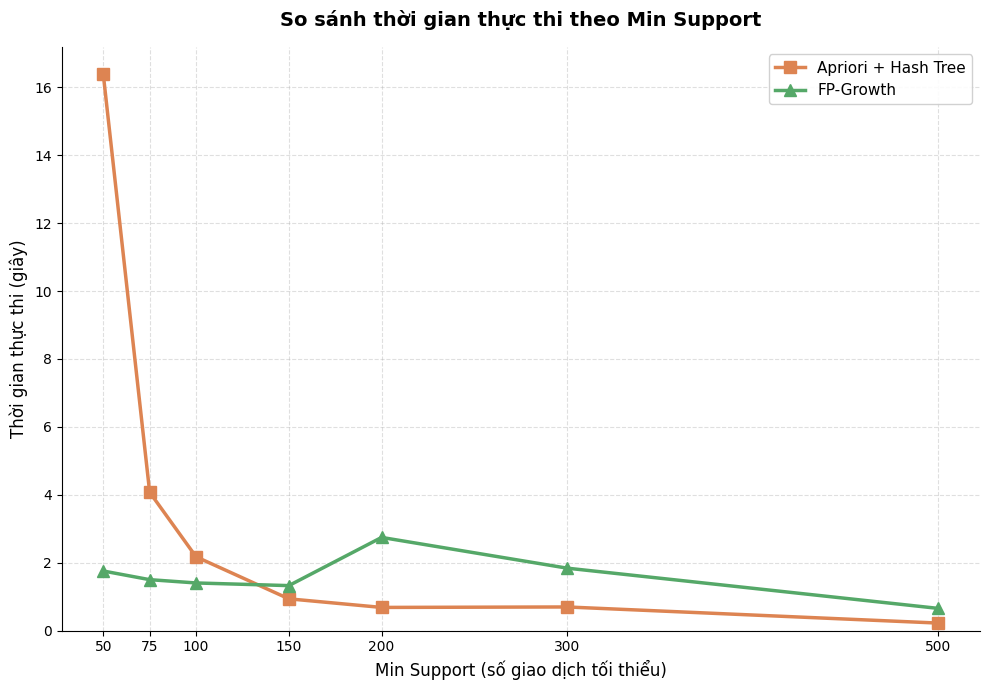

Đã lưu → outputs/runtime_comparison.png


In [11]:
# ── Vẽ biểu đồ đường ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(10, 7))


ax.plot(MIN_SUPPORT_VALUES, times_hash_tree,
        color='#DD8452', marker='s', linewidth=2.5, markersize=8,
        label='Apriori + Hash Tree')

ax.plot(MIN_SUPPORT_VALUES, times_fpgrowth,
        color='#55A868', marker='^', linewidth=2.5, markersize=8,
        label='FP-Growth')

# Nhãn giá trị trên mỗi điểm
for x, ya, yh, yf in zip(MIN_SUPPORT_VALUES, _, times_hash_tree, times_fpgrowth):
    ax.annotate(f'{yh:.1f}s', (x, yh), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color='#DD8452')
    ax.annotate(f'{yf:.1f}s', (x, yf), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color='#55A868')

ax.set_title('So sánh thời gian thực thi theo Min Support',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Min Support (số giao dịch tối thiểu)', fontsize=12)
ax.set_ylabel('Thời gian thực thi (giây)', fontsize=12)
ax.set_xticks(MIN_SUPPORT_VALUES)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(bottom=0)

plt.tight_layout()

out_dir = PROJECT_ROOT / 'outputs'
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / 'runtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu → outputs/runtime_comparison.png')